# **Bachelor Thesis Model Kernel**

**Author:** Marek Šugár

Faculty of Mathematics, Physics and Informatics Comenius University in Bratislava

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from DataFramePrep import generate_TrainingDataFrame

# Metrics to measure successfulness
from sklearn.metrics import mean_absolute_percentage_error

# ML Stuff
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.preprocessing import StandardScaler

In [3]:
TrainingDataFrame, tickers, historic_columns, StockDataDatabase = generate_TrainingDataFrame()

# **k-Nearest Neighbours (KNN) Algorithm**

Even though **k-Nearest Neighbours (KNN)** ML algorithm is considered to be rather simple, straightforward, easily interpretable and for such complex and highly volatile stock price data could be viewed as a model architecture with smaller use perspective there are a few research papers dealing with implementing such algorithm for predicting financial, thus stock data.

Nanda and his team used this technique solely in order to predict the next month EOM closing price of **Gold** (Nanda et al., 2024). Even though they had not used eny exogenous data as feature, they had done their prediction as a univariate time series, they were able to achieve a intriguing **MAPE** of $\approx 4.5 \%$. Even though this paper uses monthly frequency and principially different nature of data, yet still financial, we conclude high usability of such algorithm.

On the other hand, Afrasiabi et al. were able to implement such algorithm architecture to slightly different, yet familiar datasets dealing with predicting electricity price (Afrasiabi et al., 2019). In this paper, authors were able to predict next-day's electricity price with **MAPE** of $\approx 20.2 \%$. This paper shows us that there exist use cases in which the KNN performance is unsatisfactory.

Regarding primary use on stock prices data there are various papers dealing with such a problem. These data tend to be more "rich" in terms of larger amounts of data, which comes mostly from **daily** time frequency. There are many papers dealing with a very small subset of stocks from a specific market (mostly US market). Sakina and Khan in their paper, among larger number of more sophisticated methods, used KNN to predict next-day's prices of number of stock indices in various geographical locations. Surprisingly, KNN was superior to all the other listed architectures (e.g. SVM, RNN, LSTM) and in the monitored time interval, average MAPE $\approx 1.53 \%$ among all indices was achieved.

What is more, there are number of other studies implementing regression KNN on lists of several stocks in various locations (Huang, 2024), (Yin et al., 2025). Apart from that, classification approach using KNN has been studied as well (Patil et al., 2023).

Our focus shifts on segment stocks. There is a paper dealing with predicting next day's closing price of particular segment of S&P 500 index – **Information technology**. Building up on this paper, we have decided to implement KNN (and others in the future) algorithm on single stocks belonging to one particular segment of S&P 500, thus to biggest stocks in segment in the USA. Taking into account approaches used in previous papers we used both **regression** and **classification** approaches.

**REGRESSION APPROACH**

In [10]:
performance_trackerENPH = {}

# 3.2882596530584034

for variable_count in range(50, 541, 10):
    for ticker in ["ENPH"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2024-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 15
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerENPH[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 3.5866427304888764
60 3.5976038729639757
70 3.470205016793423
80 3.466713171538228
90 3.436621794676028
100 3.4385361022648984
110 3.358220935957134
120 3.3836811690912336
130 3.3866122747974567
140 3.399745272013226
150 3.4178149840893335
160 3.4082952360474663
170 3.417698562240054
180 3.398878419125372
190 3.398878419125372
200 3.398878419125372
210 3.3823700433157313
220 3.4193798998601634
230 3.4193798998601634
240 3.4193798998601634
250 3.4193798998601634
260 3.4193798998601634
270 3.4193798998601634
280 3.4283623251064035
290 3.3913524685619714
300 3.3913524685619714
310 3.38535574173621
320 3.3742305991408004
330 3.3742305991408004
340 3.380227325966562
350 3.37415424494328
360 3.368157518117518
370 3.3944827033047495
380 3.368157518117518
390 3.368157518117518
400 3.368157518117518
410 3.368157518117518
420 3.368157518117518
430 3.368157518117518
440 3.368157518117518
450 3.368157518117518
460 3.368157518117518
470 3.368157518117518
480 3.368157518117518
490 3.3681575181175

Text(0, 0.5, 'MAPE')

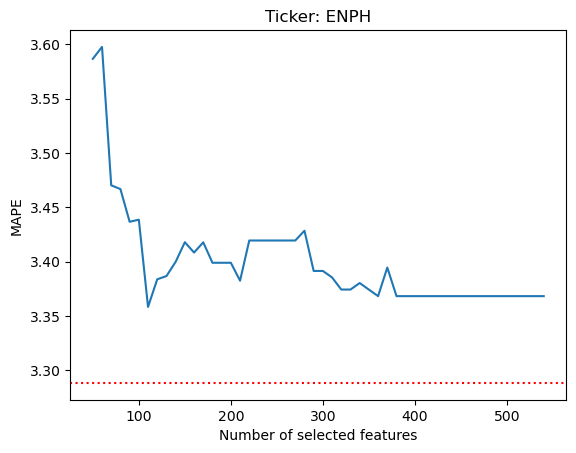

In [8]:
plt.plot(performance_trackerENPH.keys(), performance_trackerENPH.values())
plt.title("Ticker: ENPH")
plt.axhline(3.2882596530584034, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [39]:
performance_trackerROP = {}

for variable_count in range(50, 541, 10):
    for ticker in ["ROP"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerROP[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 1.0608631088725466
60 1.0687836497625531
70 1.059139331525755
80 1.0583715606798294
90 1.05968738078183
100 1.0566496946631
110 1.0542289302535288
120 1.0460630738062524
130 1.04266704880654
140 1.0391104376858602
150 1.0379017740568768
160 1.037484059788582
170 1.0334546526462802
180 1.0323867506022424
190 1.031246296385302
200 1.0322570163688942
210 1.0307085175448045
220 1.0311190927438747
230 1.0296133538469152
240 1.0304364073488075
250 1.0306450239531941
260 1.0306365437319769
270 1.030124231470848
280 1.0292911247686714
290 1.028979645031324
300 1.0289336362826194
310 1.0289336362826194
320 1.0291332243992166
330 1.0287623850054408
340 1.028964593575017
350 1.028964593575017
360 1.028964593575017
370 1.028964593575017
380 1.0287623850054408
390 1.0287623850054408
400 1.0286219012893438
410 1.0287623850054408
420 1.0287623850054408
430 1.0287623850054408
440 1.0287623850054408
450 1.0287623850054408
460 1.0287623850054408
470 1.0287623850054408
480 1.0287623850054408
490 1.028

Text(0, 0.5, 'MAPE')

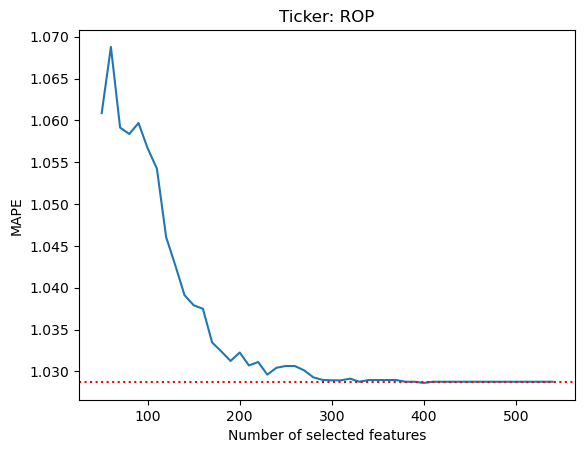

In [64]:
plt.plot(performance_trackerROP.keys(), performance_trackerROP.values())

plt.title("Ticker: ROP")
plt.axhline(1.0287623850054408, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [42]:
performance_trackerVRSN = {}

for variable_count in range(50, 541, 10):
    for ticker in ["VRSN"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerVRSN[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 1.1719538317457125
60 1.1702228950718117
70 1.1661890214450692
80 1.1636899317782283
90 1.16307409036782
100 1.158660067991848
110 1.1564366479669503
120 1.153661616255692
130 1.1557058310676886
140 1.153150178988364
150 1.1507437808721848
160 1.148411442597824
170 1.1488763461664495
180 1.146675828003786
190 1.1444777952988785
200 1.1425285574566075
210 1.1447932197689543
220 1.143451297613037
230 1.1426832736169472
240 1.1426382418580951
250 1.1430245066554712
260 1.1437750635602677
270 1.1445147254743635
280 1.1440735546182537
290 1.145524932042124
300 1.1431699436190261
310 1.1433577646716413
320 1.1427522017557117
330 1.1444301618963757
340 1.1444301618963757
350 1.1444301618963757
360 1.1444301618963757
370 1.1429131568381827
380 1.1429131568381827
390 1.1429131568381827
400 1.1429131568381827
410 1.1411015691435789
420 1.1411015691435789
430 1.1411015691435789
440 1.1411015691435789
450 1.1411015691435789
460 1.1411015691435789
470 1.1411015691435789
480 1.1411015691435789
49

Text(0, 0.5, 'MAPE')

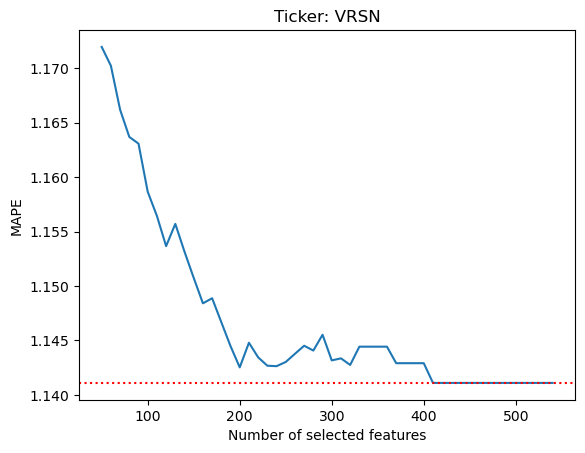

In [63]:
plt.plot(performance_trackerVRSN.keys(), performance_trackerVRSN.values())
plt.title("Ticker: VRSN")
plt.axhline(1.1411015691435789, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [59]:
performance_trackerCSCO = {}

for variable_count in range(50, 541, 10):
    for ticker in ["CSCO"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=mutual_info_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerCSCO[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))
# 1.1650666341016036

50 1.1636476188144813
60 1.1503684936454228
70 1.1482435836801643
80 1.1429079923626069
90 1.1347492126649843
100 1.131794635161089
110 1.129048002080269
120 1.1237578250077622
130 1.1199317393193542
140 1.1176390356128718
150 1.1171569961989758
160 1.1149591585122627
170 1.114008248606153
180 1.108748114872104
190 1.1088992667892945
200 1.111821951410459
210 1.1086485443750478
220 1.1082411455429173
230 1.1079978386767442
240 1.1082889927804078
250 1.1047365324781588
260 1.1053942162565151
270 1.106182605938894
280 1.1050744061688302
290 1.1058270166463449
300 1.1042260498250516
310 1.1037363426531523
320 1.1048694844474487
330 1.1039114544922655
340 1.1037016701651572
350 1.1033862339940748
360 1.1035436842518689
370 1.1044133217753815
380 1.1046028224676354
390 1.1047747457507322
400 1.1033366179468036
410 1.1043524451200624
420 1.1041654300044592
430 1.1034569454419845
440 1.103691347664916
450 1.103691347664916
460 1.104209250572892
470 1.1039814993175632
480 1.1042521527165736
49

Text(0, 0.5, 'MAPE')

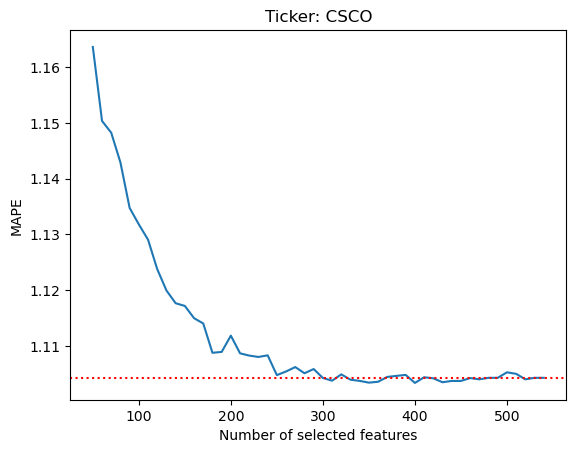

In [62]:
plt.plot(performance_trackerCSCO.keys(), performance_trackerCSCO.values())
plt.title("Ticker: CSCO")
plt.axhline(1.1042521527165736, linestyle="dotted", c="red")

plt.xlabel("Number of selected features")
plt.ylabel("MAPE")

In [66]:
performance_trackerCSCO2 = {}

for variable_count in range(50, 541, 10):
    for ticker in ["CSCO"]:
        Stock_Data = pd.read_sql(
            f"SELECT * FROM StockData WHERE Ticker='{ticker}' AND Date>='2017-09-14'",
            con=StockDataDatabase, parse_dates=["Date"]
        )
        
        Stock_Data = pd.merge(Stock_Data, TrainingDataFrame, on="Date")
        Stock_Data["Target"] = Stock_Data["Close"]
        Stock_Data = Stock_Data.dropna().reset_index(drop=True)

        training_length = 5
        prediction_length = 1

        MAPEs = []

        for window_start in range(len(Stock_Data) - (training_length + prediction_length)):
            # Define feature and target windows
            Training_Features = Stock_Data[historic_columns].iloc[window_start:window_start+training_length]
            Training_Target = Stock_Data["Target"].iloc[window_start:window_start+training_length]

            Test_Features = Stock_Data[historic_columns].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]
            Test_Target = Stock_Data["Target"].iloc[
                window_start+training_length : window_start+training_length+prediction_length
            ]

            # Skip empty slices
            if Training_Features.empty or Test_Features.empty:
                continue

            # Feature selection
            selector = SelectKBest(score_func=f_regression, k=variable_count)
            selector.fit(Training_Features, Training_Target)
            selected_features = Training_Features.columns[selector.get_support()]

            # Scale only selected features
            scaler = StandardScaler()
            Training_Features = scaler.fit_transform(Training_Features[selected_features])
            Test_Features = scaler.transform(Test_Features[selected_features])

            # Fit KNN
            MODEL = KNeighborsRegressor(n_neighbors=1)
            MODEL.fit(Training_Features, Training_Target)

            # Predict and evaluate
            prediction = MODEL.predict(Test_Features)
            MAPEs.append(100 * mean_absolute_percentage_error(Test_Target, prediction))
        
        # Save results
        performance_trackerCSCO2[variable_count] = np.mean(MAPEs)
        print(variable_count, np.mean(MAPEs))


50 1.1650666341016036
60 1.1498188157321454
70 1.1438347520225014
80 1.1306172240260228
90 1.1198160218948492
100 1.11908888987742
110 1.115189525629292
120 1.1151185908545778
130 1.1182769651502107
140 1.1173464450841735
150 1.1175661150561016
160 1.1155159019670726
170 1.1119178940683618
180 1.112124908892753
190 1.1094918198959707
200 1.1084749504811848
210 1.1081967053265773
220 1.1082351125224732
230 1.106911338604687
240 1.1074856209663606
250 1.1062105291058655
260 1.106180508764672
270 1.1059582884826384
280 1.104376669121339
290 1.105893419986157
300 1.104506900707111
310 1.1045258413107544
320 1.1060425921755725
330 1.1045258413107544
340 1.1044801195949245
350 1.104750772993935
360 1.106267523858753
370 1.106267523858753
380 1.106267523858753
390 1.106267523858753
400 1.106267523858753
410 1.104750772993935
420 1.1042521527165736
430 1.1042521527165736
440 1.1042521527165736
450 1.1042521527165736
460 1.1042521527165736
470 1.1042521527165736
480 1.1042521527165736
490 1.104

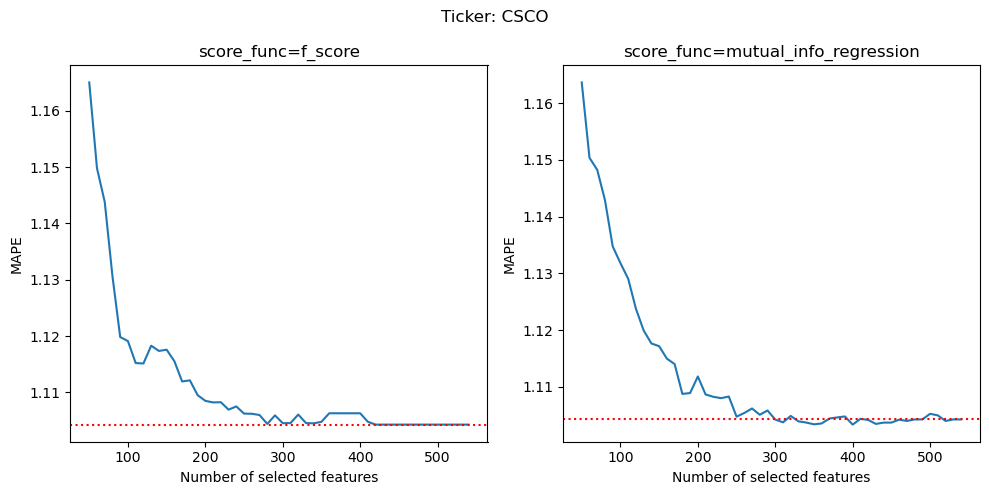

In [82]:
fig, ax = plt.subplots(1, 2)
fig.set_figheight(5)
fig.set_figwidth(10)

fig.suptitle("Ticker: CSCO")

ax[0].plot(performance_trackerCSCO2.keys(), performance_trackerCSCO2.values())
ax[0].axhline(1.1042521527165736, linestyle="dotted", c="red")

ax[0].set_xlabel("Number of selected features")
ax[0].set_ylabel("MAPE")
ax[1].set_title("score_func=mutual_info_regression")

ax[1].plot(performance_trackerCSCO.keys(), performance_trackerCSCO.values())
ax[1].axhline(1.1042521527165736, linestyle="dotted", c="red")

ax[1].set_xlabel("Number of selected features")
ax[1].set_ylabel("MAPE")
ax[0].set_title("score_func=f_score")

plt.tight_layout()
plt.show()